In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## EDA

In [2]:
df = pd.read_csv("../data/goldstock v2.csv")

In [3]:
df.head()

,Unnamed: 0,Date,Close/Last,Volume,Open,High,Low
0,0,2024-07-03,2369.4,185930.0,2338.6,2374.5,2335.7
1,1,2024-07-02,2333.4,146568.0,2341.6,2346.1,2327.4
2,2,2024-07-01,2338.9,136861.0,2336.2,2348.8,2328.2
3,3,2024-06-28,2339.6,131191.0,2338.6,2350.6,2329.7
4,4,2024-06-27,2336.6,135784.0,2309.4,2342.0,2306.8


In [4]:
print(df.columns)

Index(['Unnamed: 0', 'Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low'], dtype='object')


In [5]:
df = df.drop(columns=['Unnamed: 0'])

In [6]:
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,2024-07-03,2369.4,185930.0,2338.6,2374.5,2335.7
1,2024-07-02,2333.4,146568.0,2341.6,2346.1,2327.4
2,2024-07-01,2338.9,136861.0,2336.2,2348.8,2328.2
3,2024-06-28,2339.6,131191.0,2338.6,2350.6,2329.7
4,2024-06-27,2336.6,135784.0,2309.4,2342.0,2306.8


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
#Sort date chronologically

df = df.sort_values('Date')
df = df.reset_index(drop=True)

In [9]:
df.head()

,Date,Close/Last,Volume,Open,High,Low
0,2014-07-07,1317.0,79110.0,1321.4,1321.7,1312.1
1,2014-07-08,1316.5,126706.0,1320.8,1325.7,1314.3
2,2014-07-09,1324.3,155101.0,1320.4,1333.4,1318.7
3,2014-07-10,1339.2,167391.0,1325.0,1346.8,1325.0
4,2014-07-11,1337.4,88470.0,1336.5,1340.4,1334.6


Plot the gold

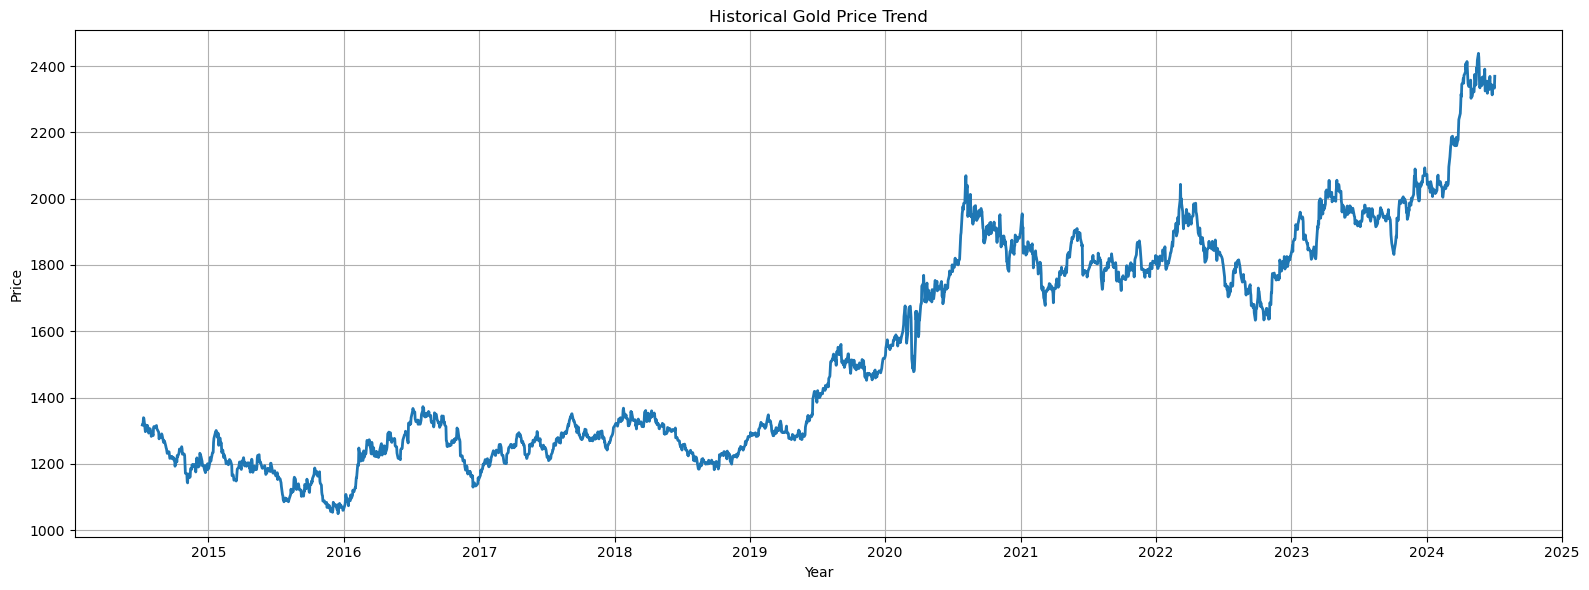

In [10]:
plt.figure(figsize=(16,6))

plt.plot(
    df['Date'],
    df['Close/Last'],
    linewidth=2
)

plt.title("Historical Gold Price Trend")

plt.xlabel("Year")

plt.ylabel("Price")

plt.grid()

plt.tight_layout()

plt.show()

## Volatile segmentation

- Volatility should usually be based on returns, not raw prices.
- Volatility measures how much returns fluctuate.

In [11]:
#calculate returns

df['returns'] = df['Close/Last'].pct_change()

In [12]:
df['volatility'] = df['returns'].rolling(
    window=10
).std()

In [13]:
#There are many NaN for the first 10 days, because there isn't any data to refer for the initial 10 days.

df[['Date','Close/Last','volatility']].head(35)

,Date,Close/Last,volatility
0,2014-07-07,1317.0,NaN
1,2014-07-08,1316.5,NaN
2,2014-07-09,1324.3,NaN
3,2014-07-10,1339.2,NaN
4,2014-07-11,1337.4,NaN
5,2014-07-14,1306.7,NaN
6,2014-07-15,1297.1,NaN
7,2014-07-16,1299.8,NaN
8,2014-07-17,1316.9,NaN
9,2014-07-18,1309.4,NaN


Compute Threshold

In [14]:
#This calculates the volatility cut off point

vol_mean = df['volatility'].mean()
vol_std = df['volatility'].std()

threshold = vol_mean + 2*vol_std

print(threshold)

0.01590992114867454


Categorize the Regimes (Stable, Volatile)

In [15]:
df['regime'] = np.where(
    df['volatility'] > threshold,
    'volatile',
    'stable'
)

In [16]:
df[['Date','volatility','regime']].tail()

,Date,volatility,regime
2506,2024-06-27,0.011154,stable
2507,2024-06-28,0.009848,stable
2508,2024-07-01,0.008824,stable
2509,2024-07-02,0.008394,stable
2510,2024-07-03,0.009450,stable


In [17]:
df['regime'].value_counts()

regime
stable      2406
volatile     105
Name: count, dtype: int64

Plot Volatility and the Threshold

- The high spikes might indicate major events, causes high volatility.

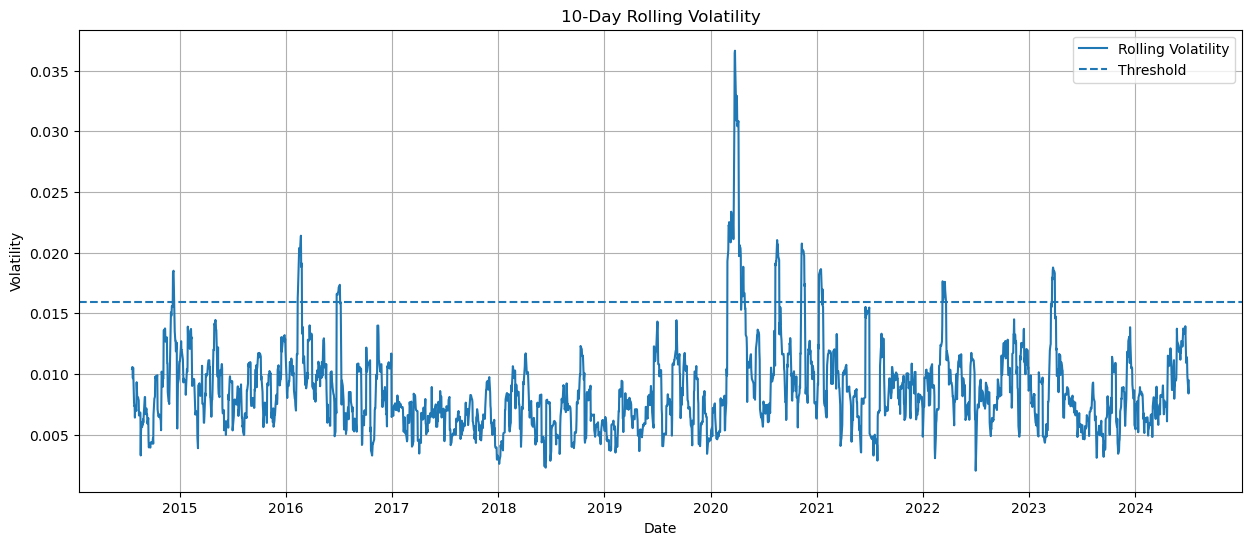

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['volatility'],
    label='Rolling Volatility'
)

plt.axhline(
    threshold,
    linestyle='--',
    label='Threshold'
)

plt.title(
    "10-Day Rolling Volatility"
)

plt.xlabel("Date")
plt.ylabel("Volatility")

plt.legend()

plt.grid()

plt.show()

Plot Stable vs Volatile Periods

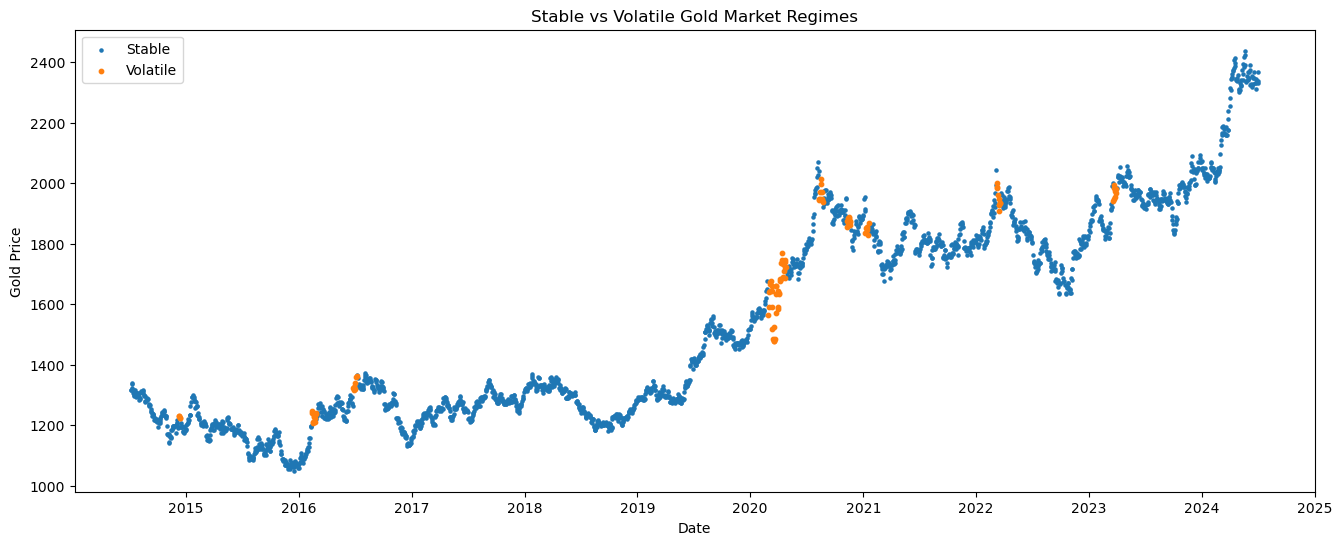

In [19]:
plt.figure(figsize=(16,6))

stable = df[df['regime']=='stable']

volatile = df[df['regime']=='volatile']

plt.scatter(
    stable['Date'],
    stable['Close/Last'],
    s=5,
    label='Stable'
)

plt.scatter(
    volatile['Date'],
    volatile['Close/Last'],
    s=10,
    label='Volatile'
)

plt.title(
    'Stable vs Volatile Gold Market Regimes'
)

plt.xlabel("Date")

plt.ylabel("Gold Price")

plt.legend()

plt.show()

## Model Comparison Methodology

- Vanilla, Informer, TFT

For each model, we compare within the same regimes, then across different regimes, using evaluation metrics MAE, MSE, R squared.

In [20]:
#Split dataset by regime

stable_df = df[df['regime']=="stable"].copy()

volatile_df = df[df['regime']=="volatile"].copy()

print(len(stable_df))
print(len(volatile_df))

2406
105


## Prepare train and test dataset

In [21]:
# Train/test split, cannot use random split, since df is time series, need to be chronological.

def chronological_split(data):

    split_idx=int(len(data)*0.8)

    train=data[:split_idx]
    test=data[split_idx:]

    return train,test

In [22]:
stable_train,stable_test=chronological_split(
    stable_df
)

volatile_train,volatile_test=chronological_split(
    volatile_df
)

Scale the data (normalize data from 0 to 1) for more stable transformer training

- Currently only using single variable input (Closing price), so essentially using past close prices to predict the next close price.
- Will progress into multivariate inputs if possible (Open + High + Low + Close + Volume).

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

Scale Stable regime

In [24]:
stable_train_close=scaler.fit_transform(
    stable_train[['Close/Last']]
)

stable_test_close=scaler.transform(
    stable_test[['Close/Last']]
)

Scale Volatile regime

In [25]:
volatile_train_close = scaler.fit_transform(
    volatile_train[['Close/Last']]
)

volatile_test_close = scaler.transform(
    volatile_test[['Close/Last']]
)

Transformers need windows, they do not read one value at a time.

- using the past 10 days, to predict the next day

In [26]:
#Create the helper for 10 day window

def create_sequences(data,seq_len=10):

    X=[]

    y=[]

    for i in range(len(data)-seq_len):

        X.append(
            data[i:i+seq_len]
        )

        y.append(
            data[i+seq_len]
        )

    return np.array(X),np.array(y)

Window for Stable regime

In [27]:
X_stable_train,y_stable_train = create_sequences(
    stable_train_close
)

X_stable_test,y_stable_test = create_sequences(
    stable_test_close
)

Window for Volatile regime

In [28]:
X_volatile_train,y_volatile_train = create_sequences(
    volatile_train_close
)

X_volatile_test,y_volatile_test = create_sequences(
    volatile_test_close
)

For clarification, now we have the below train and test data:

X_stable_train,
y_stable_train

X_stable_test,
y_stable_test

X_volatile_train,
y_volatile_train

X_volatile_test,
y_volatile_test


With the train and test data mentioned above, we will be conducting 4 scenarios:

Within same regime:

Experiment 1 - Train: X_stable_train, Test: X_stable_test\
Experiment 2 - Train: X_volatile_train, Test: X_volatile_test

Across different regime:

Experiment 3 - Train: X_stable_train, Test: X_volatile_test\
Experiment 4 - Train: X_volatile_train, Test: X_stable_test


## Model comparison

In [29]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

Converting to tensors for transformer

In [30]:
X_stable_train = torch.FloatTensor(
    X_stable_train
)

y_stable_train = torch.FloatTensor(
    y_stable_train
)

X_stable_test = torch.FloatTensor(
    X_stable_test
)

y_stable_test = torch.FloatTensor(
    y_stable_test
)

In [31]:
X_volatile_train = torch.FloatTensor(
    X_volatile_train
)

y_volatile_train = torch.FloatTensor(
    y_volatile_train
)

X_volatile_test = torch.FloatTensor(
    X_volatile_test
)

y_volatile_test = torch.FloatTensor(
    y_volatile_test
)

## Vanilla Transformer

Defining the Vanilla Transformer

In [32]:
class VanillaTransformer(nn.Module):

    def __init__(
        self,
        input_size=1,
        d_model=64,
        nhead=4,
        num_layers=2
    ):

        super().__init__()

        self.embedding=nn.Linear(
            input_size,
            d_model
        )

        encoder_layer=nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True
        )

        self.transformer=nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc=nn.Linear(
            d_model,
            1
        )

    def forward(self,x):

        x=self.embedding(x)

        x=self.transformer(x)

        x=x[:,-1,:]

        x=self.fc(x)

        return x

Initialize Vanilla transformer

- No fine tuning of parameter as of now
- Might be possible in the future

In [33]:
model=VanillaTransformer()

criterion=nn.MSELoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

VanillaTransformer(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


### Create Training Function

In [34]:
def train_model(
    X_train,
    y_train,
    epochs=100
):

    model=VanillaTransformer()

    criterion=nn.MSELoss()

    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        outputs=model(
            X_train
        )

        loss=criterion(
            outputs.squeeze(),
            y_train.squeeze()
        )

        loss.backward()

        optimizer.step()

    return model

### Create Evaluate Function

In [35]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    model.eval()

    with torch.no_grad():

        pred=model(
            X_test
        )

    pred=pred.detach().cpu().tolist()

    actual=y_test.detach().cpu().tolist()

    pred=np.array(
        pred
    ).flatten()

    actual=np.array(
        actual
    ).flatten()

    mae=mean_absolute_error(
        actual,
        pred
    )

    mse=mean_squared_error(
        actual,
        pred
    )

    r2=r2_score(
        actual,
        pred
    )

    return mae,mse,r2,pred,actual

In [36]:
# Initialize result

results=[]

### Vanilla Experiment 1: (Stable -> Stable)

Train on stable

In [37]:
model_ss = train_model(
    
    X_stable_train,

    y_stable_train

)

Evaluate on stable

In [38]:
mae,mse,r2,pred,actual=\
evaluate_model(

    model_ss,

    X_stable_test,

    y_stable_test
)

print(
    "MAE:",mae
)

print(
    "MSE:",mse
)

print(
    "R2:",r2
)

MAE: 0.06429868848141977
MSE: 0.009369435942245277
R2: 0.7348344217986724


Store results

In [39]:
results.append({

"Model":"Vanilla",

"Train":"Stable",

"Test":"Stable",

"MAE":mae,

"MSE":mse,

"R2":r2

})

Plot

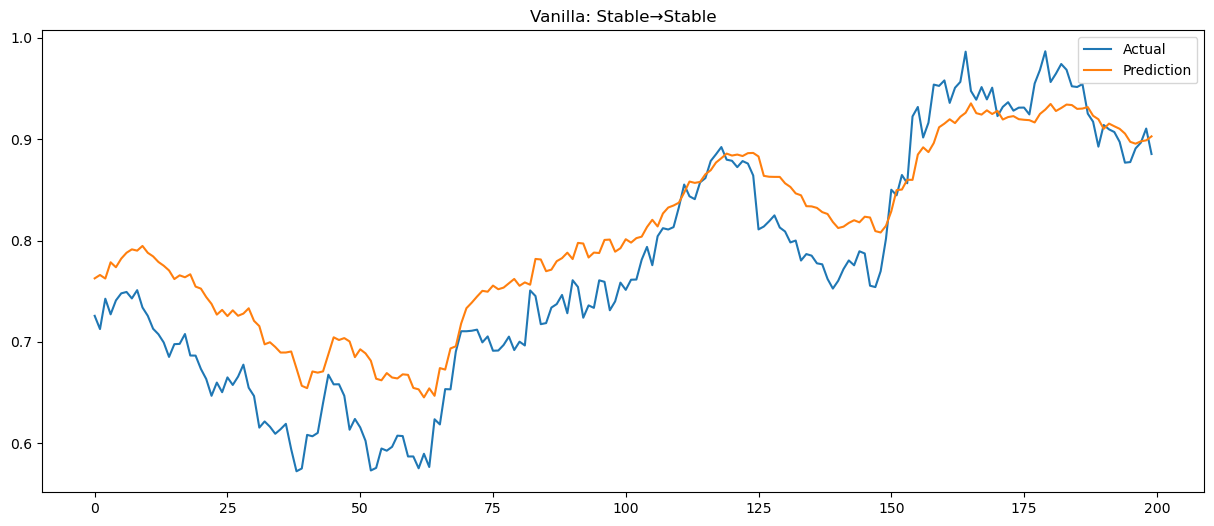

In [40]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Vanilla: Stable→Stable"
)

plt.legend()

plt.show()

### Vanilla Experiment 2: (Volatile -> Volatile)

Train on volatile

In [41]:
model_vv=train_model(
    X_volatile_train,
    y_volatile_train
)

Evaluate on volatile

In [42]:
mae,mse,r2,pred,actual=\
evaluate_model(

model_vv,

X_volatile_test,

y_volatile_test
)

print(
    mae,
    mse,
    r2
)

0.020281542431224476 0.0006199465809208442 0.008562155946176375


Store results

In [43]:
results.append({

"Model":"Vanilla",

"Train":"Volatile",

"Test":"Volatile",

"MAE":mae,

"MSE":mse,

"R2":r2
})

Plot

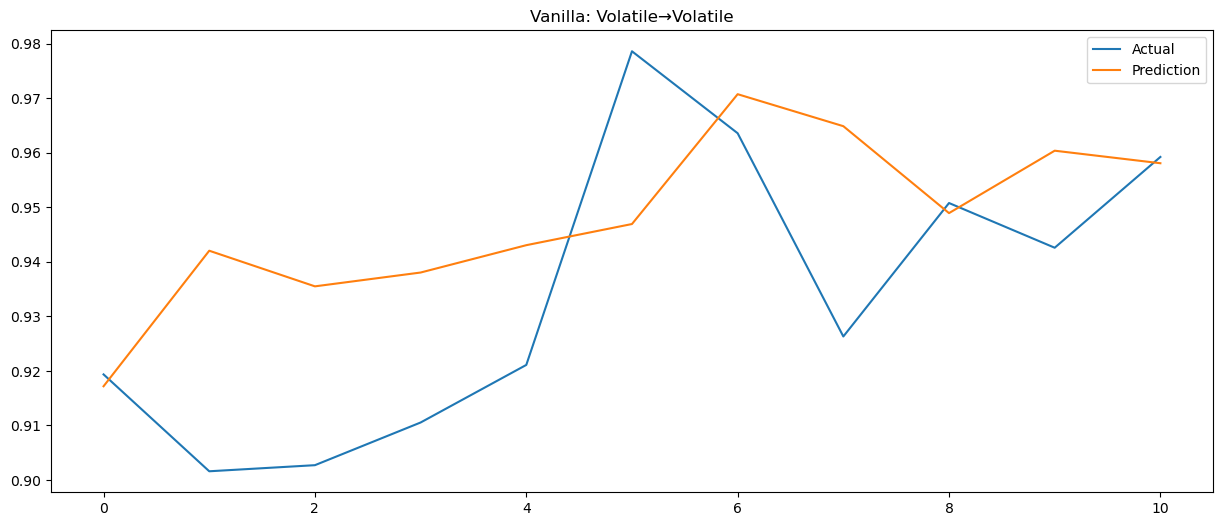

In [44]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Vanilla: Volatile→Volatile"
)

plt.legend()

plt.show()

### Vanilla Experiment 3: (Stable -> Volatile)

Train on stable

In [45]:
model_sv=train_model(

X_stable_train,

y_stable_train
)

Evaluate on volatile

In [46]:
mae,mse,r2,pred,actual=\
evaluate_model(

model_sv,

X_volatile_test,

y_volatile_test
)

Store results

In [47]:
results.append({

"Model":"Vanilla",

"Train":"Stable",

"Test":"Volatile",

"MAE":mae,

"MSE":mse,

"R2":r2
})

Plot

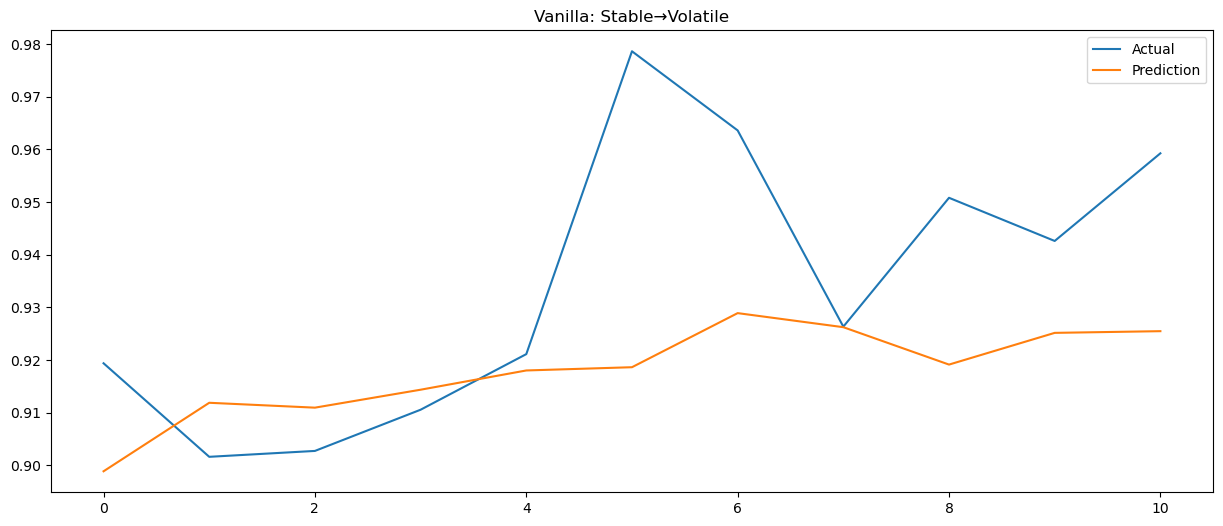

In [48]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Vanilla: Stable→Volatile"
)

plt.legend()
plt.show()

### Vanilla Experiment 4: (Volatile -> Stable)

Train on volatile

In [49]:
model_vs=train_model(

X_volatile_train,

y_volatile_train
)

Evaluate on stable

In [50]:
mae,mse,r2,pred,actual=\
evaluate_model(

model_vs,

X_stable_test,

y_stable_test
)

Store results

In [51]:
results.append({

"Model":"Vanilla",

"Train":"Volatile",

"Test":"Stable",

"MAE":mae,

"MSE":mse,

"R2":r2
})

Plot

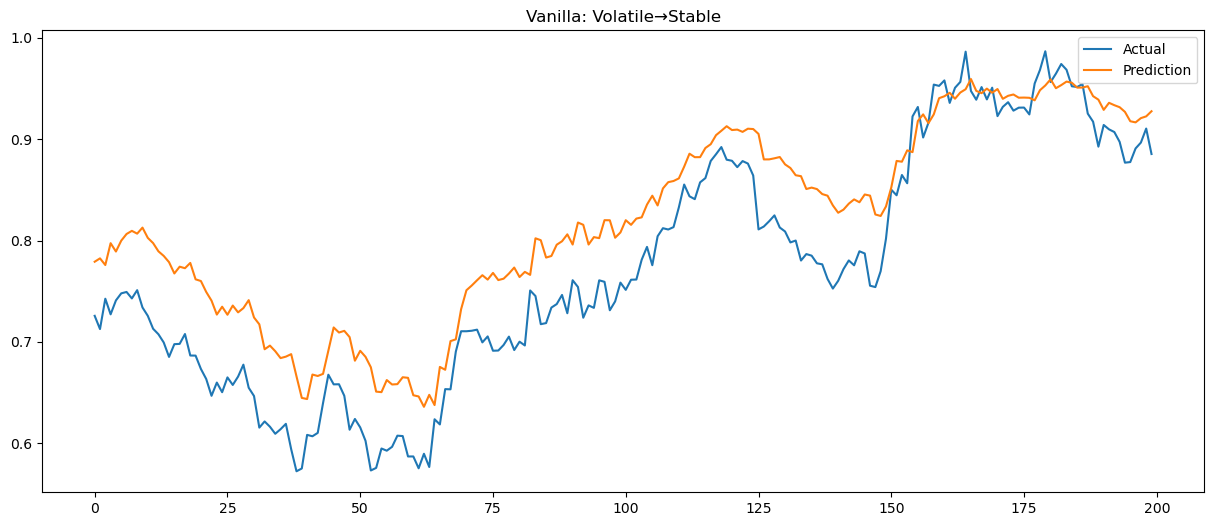

In [52]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Vanilla: Volatile→Stable"
)

plt.legend()
plt.show()

### Vanilla Final Results and Explanation

In [53]:
Vanilla_results_df=pd.DataFrame(
    results
)

Vanilla_results_df

,Model,Train,Test,MAE,MSE,R2
0,Vanilla,Stable,Stable,0.064299,0.009369,0.734834
1,Vanilla,Volatile,Volatile,0.020282,0.000620,0.008562
2,Vanilla,Stable,Volatile,0.020330,0.000716,-0.144574
3,Vanilla,Volatile,Stable,0.067537,0.009474,0.731873


#### 1. Stable → Stable

R² = 0.735

Explanation:

- Strong performance
- Stable markets contain smoother trends
- Gold prices become easier to predict
- Transformer captures repeating temporal patterns

Stable periods exhibit more regular temporal behavior, allowing the Transformer to learn meaningful dependencies effectively.

#### 2. Volatile → Volatile

R² = 0.009

Explanation:

- Very weak performance
- Volatile periods contain abrupt spikes
- Attention mechanism struggles because future movement becomes less predictable.

Even though MSE looks small: 0.0006, this does not imply strong learning.

R² near zero means model barely improves over average prediction

#### 3. Stable → Volatile

R² = −0.145

Explanation:

Negative R² means result is worse than predicting the mean.

Model learned:

-smooth behavior, then encountered market shocks.

This demonstrates poor regime transfer.

Features learned under stable conditions do not generalize well to highly volatile market behavior.

#### 4. Volatile → Stable

R² = 0.732

Surprisingly strong.

Explanation:

- Volatile data contains both stable movement and large fluctuations.
- Training on harder patterns sometimes generalizes better.

Model learned richer behavior.

## Informer Transformer with ProbSparse mechanism

In [54]:
import torch
import torch.nn as nn

In [55]:
results=[]

In [56]:
import sys
import os

sys.path.append(
    os.path.abspath("../Informer2020")
)

In [57]:
from models.model import Informer

In [58]:
print(X_stable_train.shape)

print(X_stable_test.shape)

print(X_volatile_train.shape)

print(X_volatile_test.shape)

torch.Size([1914, 10, 1])
torch.Size([472, 10, 1])
torch.Size([74, 10, 1])
torch.Size([11, 10, 1])


#### Create Informer model

In [59]:
def create_informer():

    model = Informer(

        enc_in=1,

        dec_in=1,

        c_out=1,

        seq_len=10,

        label_len=5,

        out_len=1,

        factor=5,

        d_model=64,

        n_heads=4,

        e_layers=2,

        d_layers=1,

        dropout=0.05,

        attn='prob',

        embed='timeF',

        freq='d',

        activation='gelu',

        output_attention=False,

        distil=True,

        mix=True,

        device='cpu'

    )

    return model

### Create dummy time features as placeholder

- Since Informer typically accepts (month, day, weekday, hour)

In [60]:
def create_time_marks(X):

    batch=X.shape[0]

    seq=X.shape[1]

    return torch.zeros(
        batch,
        seq,
        3
    )

### Training function

In [61]:
def train_informer(
    X_train,
    y_train,
    epochs=100
):

    model=create_informer()

    criterion=nn.MSELoss()

    optimizer=torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    x_mark_enc=create_time_marks(
        X_train
    )

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        dec_inp=torch.zeros(

            X_train.shape[0],

            6,

            1
        )

        x_mark_dec=torch.zeros(

            X_train.shape[0],

            6,

            3
        )

        outputs=model(

            X_train,

            x_mark_enc,

            dec_inp,

            x_mark_dec
        )

        loss=criterion(

            outputs.squeeze(),

            y_train.squeeze()
        )

        loss.backward()

        optimizer.step()

        print(
            f"Epoch {epoch+1}: {loss.item():.5f}"
        )

    return model

### Evaluation function 

In [62]:
def evaluate_informer(

    model,

    X_test,

    y_test

):

    model.eval()

    x_mark_enc=create_time_marks(
        X_test
    )

    with torch.no_grad():

        dec_inp=torch.zeros(

            X_test.shape[0],

            6,

            1
        )

        x_mark_dec=torch.zeros(

            X_test.shape[0],

            6,

            3
        )

        pred=model(

            X_test,

            x_mark_enc,

            dec_inp,

            x_mark_dec
        )

    pred=np.array(
        pred.detach()
        .cpu()
        .tolist()
    ).flatten()

    actual=np.array(
        y_test.detach()
        .cpu()
        .tolist()
    ).flatten()

    mae=mean_absolute_error(
        actual,
        pred
    )

    mse=mean_squared_error(
        actual,
        pred
    )

    r2=r2_score(
        actual,
        pred
    )

    return mae,mse,r2,pred,actual

### Informer Experiment 1 (Stable -> Stable)

In [63]:
results=[]

Train using Stable

In [64]:
model_ss=train_informer(

    X_stable_train,

    y_stable_train
)

Epoch 1: 0.20929
Epoch 2: 0.88826
Epoch 3: 0.22329
Epoch 4: 0.14551
Epoch 5: 0.19010
Epoch 6: 0.14465
Epoch 7: 0.11016
Epoch 8: 0.10815
Epoch 9: 0.11737
Epoch 10: 0.10410
Epoch 11: 0.07466
Epoch 12: 0.03403
Epoch 13: 0.01305
Epoch 14: 0.01774
Epoch 15: 0.03405
Epoch 16: 0.04360
Epoch 17: 0.03827
Epoch 18: 0.02663
Epoch 19: 0.01549
Epoch 20: 0.01219
Epoch 21: 0.01566
Epoch 22: 0.01824
Epoch 23: 0.01803
Epoch 24: 0.01572
Epoch 25: 0.01337
Epoch 26: 0.01320
Epoch 27: 0.01486
Epoch 28: 0.01565
Epoch 29: 0.01456
Epoch 30: 0.01214
Epoch 31: 0.00806
Epoch 32: 0.00719
Epoch 33: 0.00780
Epoch 34: 0.00935
Epoch 35: 0.01024
Epoch 36: 0.00951
Epoch 37: 0.00871
Epoch 38: 0.00796
Epoch 39: 0.00755
Epoch 40: 0.00809
Epoch 41: 0.00783
Epoch 42: 0.00730
Epoch 43: 0.00627
Epoch 44: 0.00611
Epoch 45: 0.00609
Epoch 46: 0.00644
Epoch 47: 0.00678
Epoch 48: 0.00692
Epoch 49: 0.00629
Epoch 50: 0.00614
Epoch 51: 0.00551
Epoch 52: 0.00555
Epoch 53: 0.00573
Epoch 54: 0.00551
Epoch 55: 0.00558
Epoch 56: 0.00525
E

Evaluate using Stable

In [65]:
mae,mse,r2,pred,actual=\
evaluate_informer(

    model_ss,

    X_stable_test,

    y_stable_test
)

print(
    "MAE:",mae
)

print(
    "MSE:",mse
)

print(
    "R2:",r2
)

MAE: 0.12029884641958495
MSE: 0.029859089538425213
R2: 0.1549541732472346


Store results

In [66]:
results.append({

"Model":"Informer",

"Train":"Stable",

"Test":"Stable",

"MAE":mae,

"MSE":mse,

"R2":r2

})

Plot

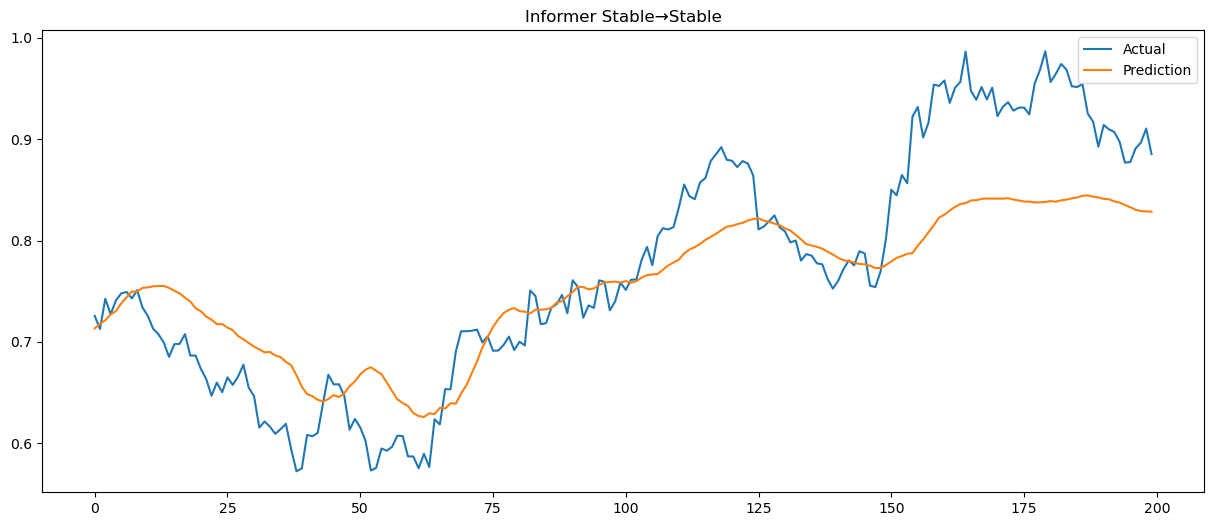

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Informer Stable→Stable"
)

plt.legend()

plt.show()

### Informer Experiment 2 (Volatile -> Volatile)

Train on volatile

In [68]:
model_vv=train_informer(

    X_volatile_train,

    y_volatile_train
)

Epoch 1: 0.17007
Epoch 2: 0.33658
Epoch 3: 0.14924
Epoch 4: 0.19628
Epoch 5: 0.07252
Epoch 6: 0.04763
Epoch 7: 0.10104
Epoch 8: 0.11593
Epoch 9: 0.04616
Epoch 10: 0.02733
Epoch 11: 0.04106
Epoch 12: 0.05758
Epoch 13: 0.04581
Epoch 14: 0.02952
Epoch 15: 0.02358
Epoch 16: 0.02949
Epoch 17: 0.04300
Epoch 18: 0.04239
Epoch 19: 0.02584
Epoch 20: 0.02379
Epoch 21: 0.02784
Epoch 22: 0.02647
Epoch 23: 0.02600
Epoch 24: 0.02033
Epoch 25: 0.01916
Epoch 26: 0.01488
Epoch 27: 0.01852
Epoch 28: 0.02573
Epoch 29: 0.01910
Epoch 30: 0.01669
Epoch 31: 0.01496
Epoch 32: 0.01780
Epoch 33: 0.01498
Epoch 34: 0.01545
Epoch 35: 0.01117
Epoch 36: 0.01665
Epoch 37: 0.01810
Epoch 38: 0.01288
Epoch 39: 0.01698
Epoch 40: 0.01274
Epoch 41: 0.01146
Epoch 42: 0.01342
Epoch 43: 0.01116
Epoch 44: 0.01023
Epoch 45: 0.00953
Epoch 46: 0.01244
Epoch 47: 0.01119
Epoch 48: 0.01220
Epoch 49: 0.00908
Epoch 50: 0.01194
Epoch 51: 0.00980
Epoch 52: 0.00785
Epoch 53: 0.00909
Epoch 54: 0.01040
Epoch 55: 0.00818
Epoch 56: 0.00897
E

Evaluate on volatile

In [69]:
mae,mse,r2,pred,actual=\
evaluate_informer(

    model_vv,

    X_volatile_test,

    y_volatile_test
)

print(
    "MAE:",mae
)

print(
    "MSE:",mse
)

print(
    "R2:",r2
)

MAE: 0.0548093318939209
MSE: 0.003347766836379859
R2: -4.353852794421855


Store results

In [70]:
results.append({

"Model":"Informer",

"Train":"Volatile",

"Test":"Volatile",

"MAE":mae,

"MSE":mse,

"R2":r2

})

Plot

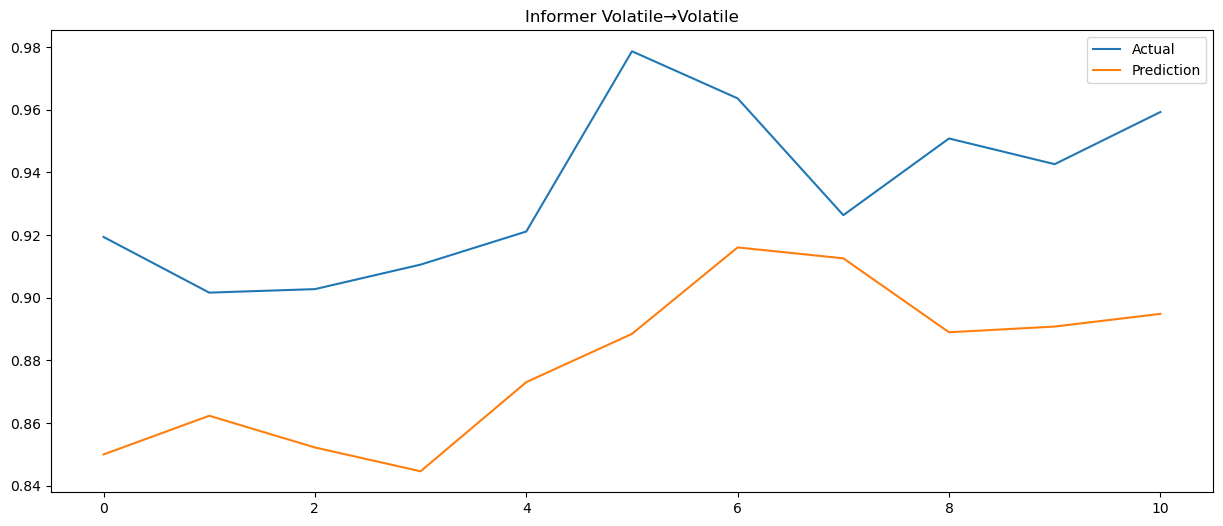

In [71]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Informer Volatile→Volatile"
)

plt.legend()

plt.show()

### Informer Experiment 3 (Stable -> Volatile)

Train on Stable

In [72]:
model_sv=train_informer(

    X_stable_train,

    y_stable_train
)

Epoch 1: 0.10640
Epoch 2: 0.31888
Epoch 3: 0.06315
Epoch 4: 0.12546
Epoch 5: 0.08198
Epoch 6: 0.05204
Epoch 7: 0.06919
Epoch 8: 0.07036
Epoch 9: 0.04158
Epoch 10: 0.01773
Epoch 11: 0.01067
Epoch 12: 0.01982
Epoch 13: 0.02635
Epoch 14: 0.02126
Epoch 15: 0.01355
Epoch 16: 0.00908
Epoch 17: 0.01262
Epoch 18: 0.01650
Epoch 19: 0.01562
Epoch 20: 0.01154
Epoch 21: 0.00910
Epoch 22: 0.00985
Epoch 23: 0.01237
Epoch 24: 0.01225
Epoch 25: 0.00978
Epoch 26: 0.00709
Epoch 27: 0.00645
Epoch 28: 0.00775
Epoch 29: 0.00887
Epoch 30: 0.00910
Epoch 31: 0.00718
Epoch 32: 0.00610
Epoch 33: 0.00590
Epoch 34: 0.00659
Epoch 35: 0.00673
Epoch 36: 0.00621
Epoch 37: 0.00525
Epoch 38: 0.00558
Epoch 39: 0.00545
Epoch 40: 0.00606
Epoch 41: 0.00611
Epoch 42: 0.00490
Epoch 43: 0.00472
Epoch 44: 0.00490
Epoch 45: 0.00495
Epoch 46: 0.00518
Epoch 47: 0.00440
Epoch 48: 0.00444
Epoch 49: 0.00429
Epoch 50: 0.00429
Epoch 51: 0.00433
Epoch 52: 0.00409
Epoch 53: 0.00380
Epoch 54: 0.00424
Epoch 55: 0.00410
Epoch 56: 0.00427
E

Evaluate on Volatile

In [73]:
mae,mse,r2,pred,actual=\
evaluate_informer(

    model_sv,

    X_volatile_test,

    y_volatile_test
)

Store results

In [74]:
results.append({

"Model":"Informer",

"Train":"Stable",

"Test":"Volatile",

"MAE":mae,

"MSE":mse,

"R2":r2

})

Plot

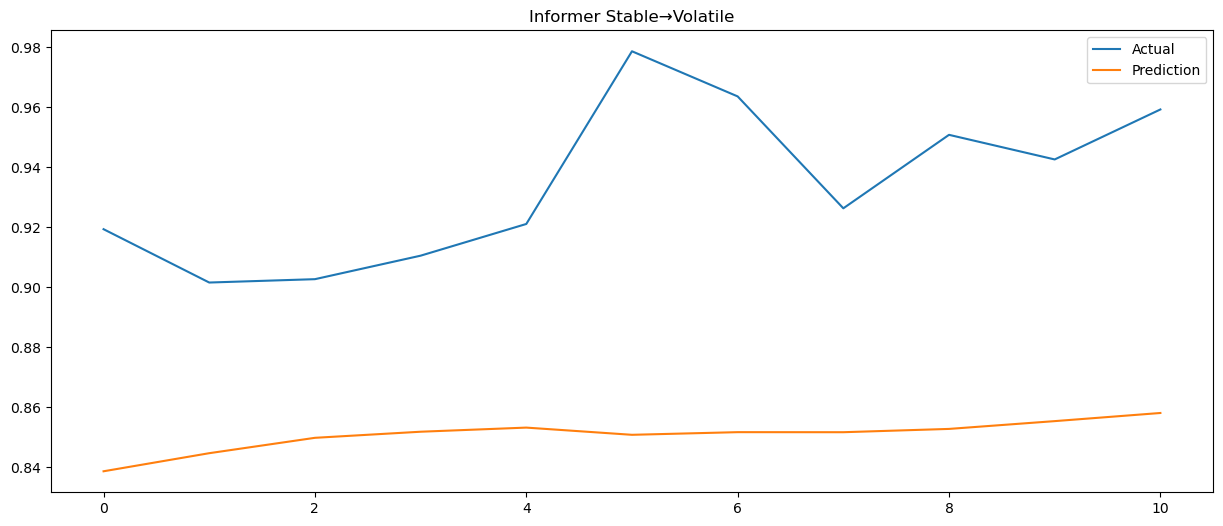

In [75]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Informer Stable→Volatile"
)

plt.legend()

plt.show()

### Informer Experiment 4 (Volatile -> Stable)

Train on Volatile

In [76]:
model_vs=train_informer(

    X_volatile_train,

    y_volatile_train
)

Epoch 1: 1.19243
Epoch 2: 0.06679
Epoch 3: 0.44979
Epoch 4: 0.34836
Epoch 5: 0.11720
Epoch 6: 0.03171
Epoch 7: 0.06311
Epoch 8: 0.13109
Epoch 9: 0.12591
Epoch 10: 0.10512
Epoch 11: 0.07046
Epoch 12: 0.05076
Epoch 13: 0.04253
Epoch 14: 0.04195
Epoch 15: 0.05146
Epoch 16: 0.04136
Epoch 17: 0.03762
Epoch 18: 0.02422
Epoch 19: 0.02562
Epoch 20: 0.02702
Epoch 21: 0.03489
Epoch 22: 0.04065
Epoch 23: 0.03051
Epoch 24: 0.02752
Epoch 25: 0.01818
Epoch 26: 0.02043
Epoch 27: 0.02167
Epoch 28: 0.02181
Epoch 29: 0.02810
Epoch 30: 0.02492
Epoch 31: 0.02020
Epoch 32: 0.02115
Epoch 33: 0.02008
Epoch 34: 0.01743
Epoch 35: 0.01803
Epoch 36: 0.01760
Epoch 37: 0.01373
Epoch 38: 0.01514
Epoch 39: 0.01840
Epoch 40: 0.01469
Epoch 41: 0.01827
Epoch 42: 0.01338
Epoch 43: 0.01414
Epoch 44: 0.01337
Epoch 45: 0.01390
Epoch 46: 0.01336
Epoch 47: 0.01276
Epoch 48: 0.01225
Epoch 49: 0.01264
Epoch 50: 0.01298
Epoch 51: 0.01260
Epoch 52: 0.01062
Epoch 53: 0.01306
Epoch 54: 0.01259
Epoch 55: 0.01068
Epoch 56: 0.01193
E

Evaluate on Stable

In [77]:
mae,mse,r2,pred,actual=\
evaluate_informer(

    model_vs,

    X_stable_test,

    y_stable_test
)

Store results

In [78]:
results.append({

"Model":"Informer",

"Train":"Volatile",

"Test":"Stable",

"MAE":mae,

"MSE":mse,

"R2":r2

})

Plot

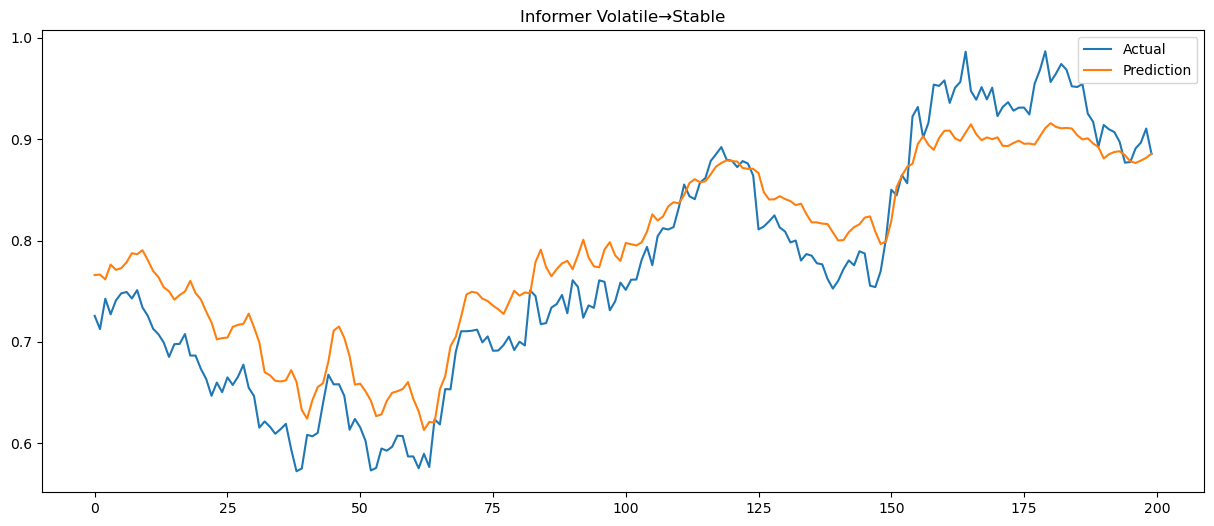

In [79]:
plt.figure(figsize=(15,6))

plt.plot(
    actual[:200],
    label='Actual'
)

plt.plot(
    pred[:200],
    label='Prediction'
)

plt.title(
    "Informer Volatile→Stable"
)

plt.legend()

plt.show()

### Informer Final Results and Explanation

In [80]:
Informer_results_df=pd.DataFrame(
    results
)

Informer_results_df

,Model,Train,Test,MAE,MSE,R2
0,Informer,Stable,Stable,0.120299,0.029859,0.154954
1,Informer,Volatile,Volatile,0.054809,0.003348,-4.353853
2,Informer,Stable,Volatile,0.083378,0.007488,-10.974816
3,Informer,Volatile,Stable,0.080660,0.017209,0.512968


#### 1. Stable → Stable

R² = 0.155

Explanation:

- Informer uses ProbSparse attention, which is designed for very long sequences.
- Our sequence of 10 days is too short.

Therefore Informer complexity may not provide benefit.

#### 2. Volatile → Volatile

R² = −4.35

Extremely poor.

Explanation:

- ProbSparse attention selects only important attention scores.
- In highly noisy volatile data, important patterns become difficult to identify.

Result:

Attention selection becomes unstable.

#### 3. Stable → Volatile

R² = −10.97

This is the overeall worst result.

Explanation:

Two problems combined:

regime shift, sparse attention simplification

- Stable training learned smooth structure.
- Volatile testing introduced abrupt unseen behavior.

Result:

large prediction collapse.

#### 4. Volatile → Stable

R² = 0.513

Better than expected.

Explanation:

- Volatile training exposes wider pattern diversity.
- Model transfers better into easier stable conditions.

Still lower than Vanilla.

## TFT Transformer

In [81]:
results=[]

In [82]:
import pandas as pd
import numpy as np
import torch

from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer
)

from pytorch_forecasting.metrics import RMSE

from lightning.pytorch import Trainer

In [83]:
tft_stable = stable_df.copy()

TFT requires sequential time index and a group ID

In [84]:
tft_stable["time_idx"] = np.arange(
    len(tft_stable)
)

tft_stable["series"]="gold"

In [85]:
tft_stable.head()

,Date,Close/Last,Volume,Open,High,Low,returns,volatility,regime,time_idx,series
0,2014-07-07,1317.0,79110.0,1321.4,1321.7,1312.1,NaN,NaN,stable,0,gold
1,2014-07-08,1316.5,126706.0,1320.8,1325.7,1314.3,-0.000380,NaN,stable,1,gold
2,2014-07-09,1324.3,155101.0,1320.4,1333.4,1318.7,0.005925,NaN,stable,2,gold
3,2014-07-10,1339.2,167391.0,1325.0,1346.8,1325.0,0.011251,NaN,stable,3,gold
4,2014-07-11,1337.4,88470.0,1336.5,1340.4,1334.6,-0.001344,NaN,stable,4,gold


### Create train/test split

In [86]:
split_idx = int(
    len(tft_stable)*0.8
)

train_df = tft_stable.iloc[
    :split_idx
]

test_df = tft_stable.iloc[
    split_idx:
]

In [87]:
max_encoder_length=10

max_prediction_length=1

### Create training dataset

In [88]:
training=TimeSeriesDataSet(

    train_df,

    time_idx="time_idx",

    target="Close/Last",

    group_ids=["series"],

    max_encoder_length=
    max_encoder_length,

    max_prediction_length=
    max_prediction_length,

    time_varying_unknown_reals=[
        "Close/Last"
    ]
)

### Create validation dataset

In [89]:
validation=TimeSeriesDataSet.from_dataset(

    training,

    test_df,

    stop_randomization=True
)

### Create dataloaders

In [90]:
train_loader=training.to_dataloader(

    train=True,

    batch_size=64
)

val_loader=validation.to_dataloader(

    train=False,

    batch_size=64
)

### Create TFT

In [91]:
tft=TemporalFusionTransformer.from_dataset(

    training,

    learning_rate=0.001,

    hidden_size=16,

    attention_head_size=4,

    dropout=0.1,

    hidden_continuous_size=8,

    output_size=1,

    loss=RMSE()

)

d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [92]:
trainer=Trainer(

    max_epochs=100,

    accelerator="cpu"

)

trainer.fit(

    tft,

    train_loader,

    val_loader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs a

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\loops\fit_loop.py:317: The number of training batches (29) is smaller than the logging

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


### Predict

In [93]:
pred=tft.predict(
    val_loader
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
d:\miniconda3\envs\gold_transformer\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


In [94]:
min_len=min(
    len(pred),
    len(actual)
)

pred=pred[:min_len]

actual=actual[:min_len]

In [95]:
print(pred[:20])

print(actual[:20])

tensor([[1794.7334],
        [1796.9414],
        [1783.9248],
        [1814.9578],
        [1798.8292],
        [1813.3164],
        [1820.9374],
        [1822.4841],
        [1815.7620],
        [1824.6333],
        [1806.3812],
        [1797.8196],
        [1784.9814],
        [1779.7469],
        [1771.9541],
        [1758.8364],
        [1770.5332],
        [1770.5835],
        [1779.6570],
        [1759.5681]])
[0.72573054 0.71268874 0.74259657 0.7272014  0.7409296  0.74789172
 0.74926454 0.74289078 0.75102961 0.73396742 0.72573054 0.71298295
 0.70758975 0.69945085 0.6852324  0.69778389 0.69807804 0.70778584
 0.68660522 0.68650717]


In [96]:
pred = scaler.transform(
    pred.reshape(-1,1)
).flatten()

d:\miniconda3\envs\gold_transformer\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


### Metrics

In [97]:
mae=mean_absolute_error(
    actual,
    pred
)

mse=mean_squared_error(
    actual,
    pred
)

r2=r2_score(
    actual,
    pred
)

print(
    "MAE:",mae
)

print(
    "MSE:",mse
)

print(
    "R2:",r2
)

MAE: 0.0880859635721073
MSE: 0.022596014648639376
R2: 0.3605073639132761


In [98]:
results.append({

"Model":"TFT",

"Train":"Stable",

"Test":"Stable",

"MAE":mae,

"MSE":mse,

"R2":r2

})

### Plot

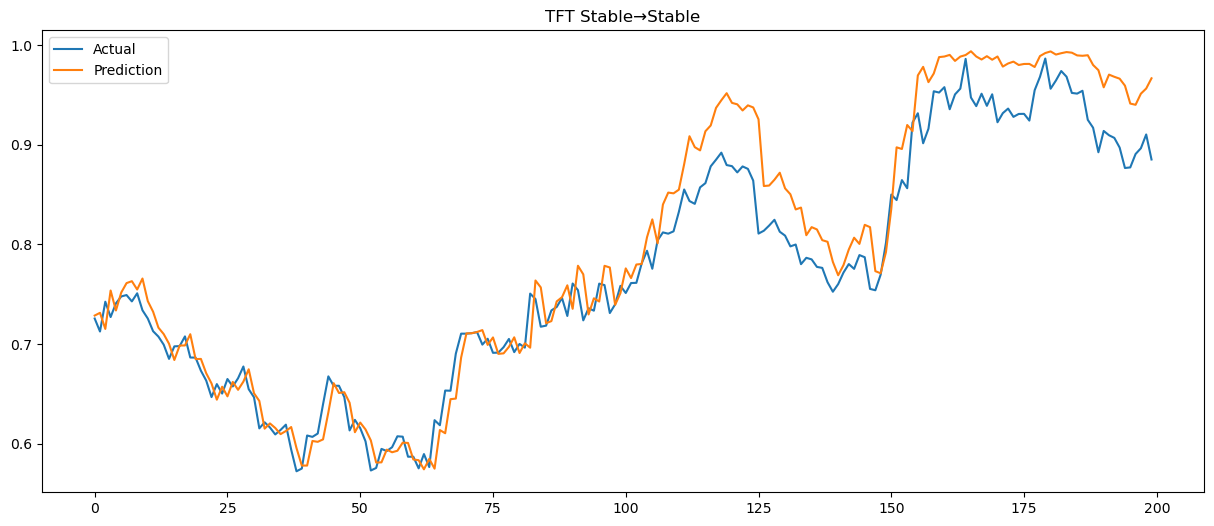

In [99]:
plt.figure(
    figsize=(15,6)
)

plt.plot(
    actual[:200],
    label="Actual"
)

plt.plot(
    pred[:200],
    label="Prediction"
)

plt.title(
    "TFT Stable→Stable"
)

plt.legend()

plt.show()

### Stable → Stable

R² = 0.361

TFT shines when many features exist:

Open
High
Low
Volume
technical indicators
regime labels

With only one feature:

variable selection contributes little.

## Overall Model Comparison

### Stable regime:

Vanilla > TFT > Informer

### Volatile regime:

All models deteriorate substantially.

Reason:

Volatility introduces:

- abrupt changes
- market shocks
- nonstationary behavior

which are harder to learn.



Results indicate that market regime significantly affects prediction performance. Models trained under stable periods generally perform well within the same regime, but experience performance degradation when transferred across regimes. Vanilla Transformer currently demonstrates the strongest overall performance, while Informer may not benefit from shorter sequence lengths used in this study. TFT performance could potentially improve by incorporating additional explanatory variables.